*Let's Make Netflix Data Visualization*

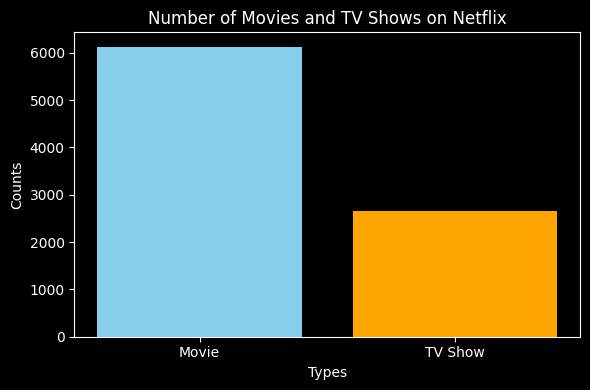

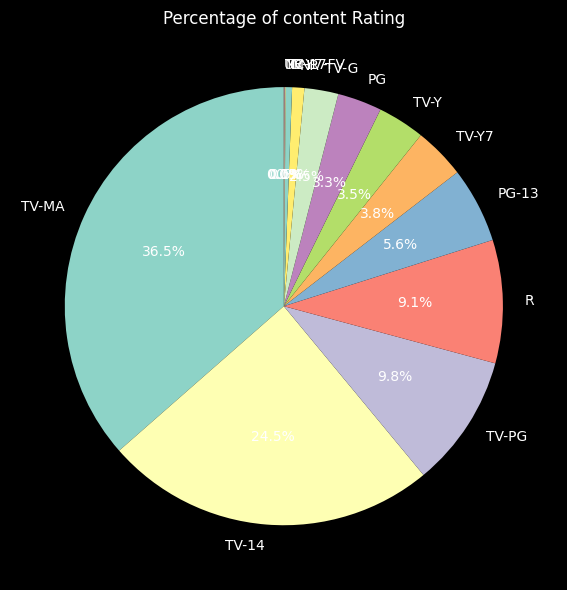

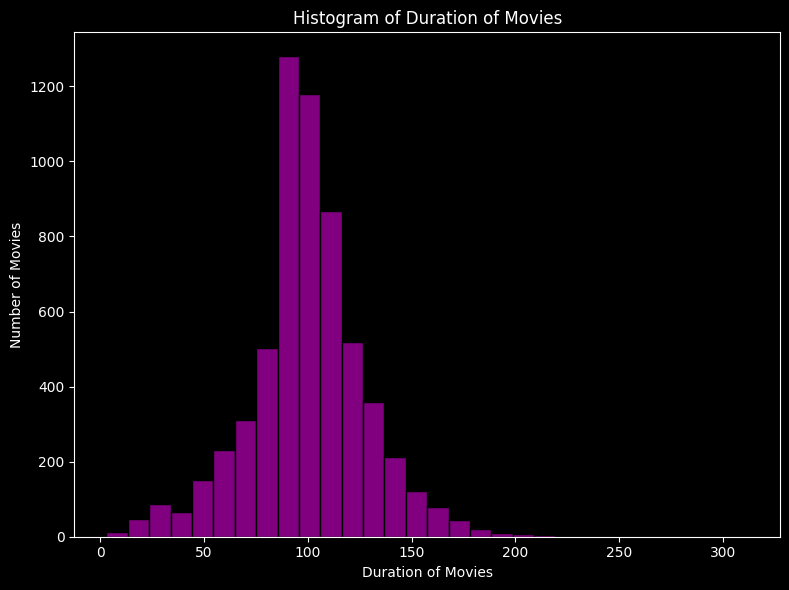

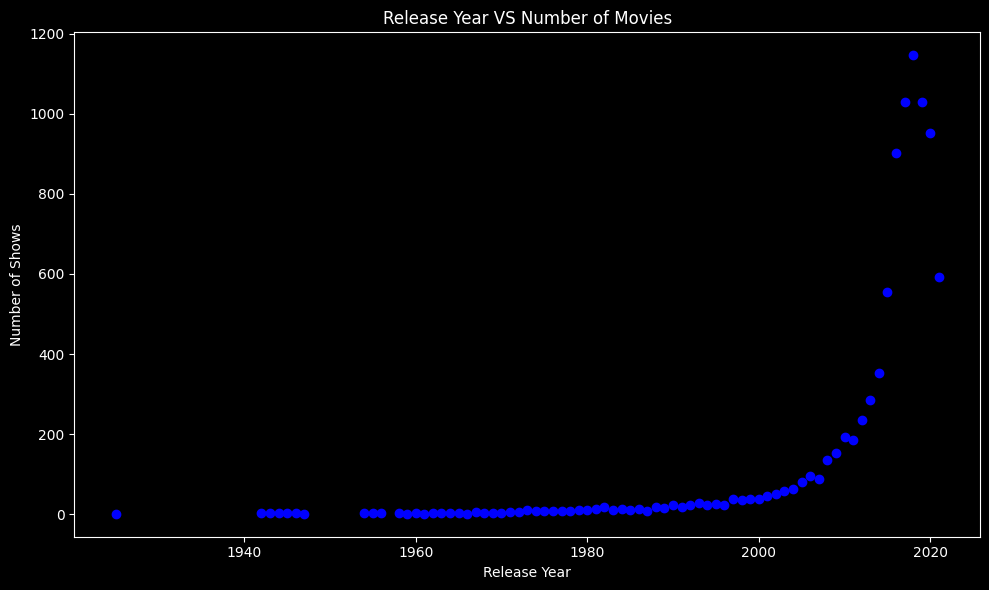

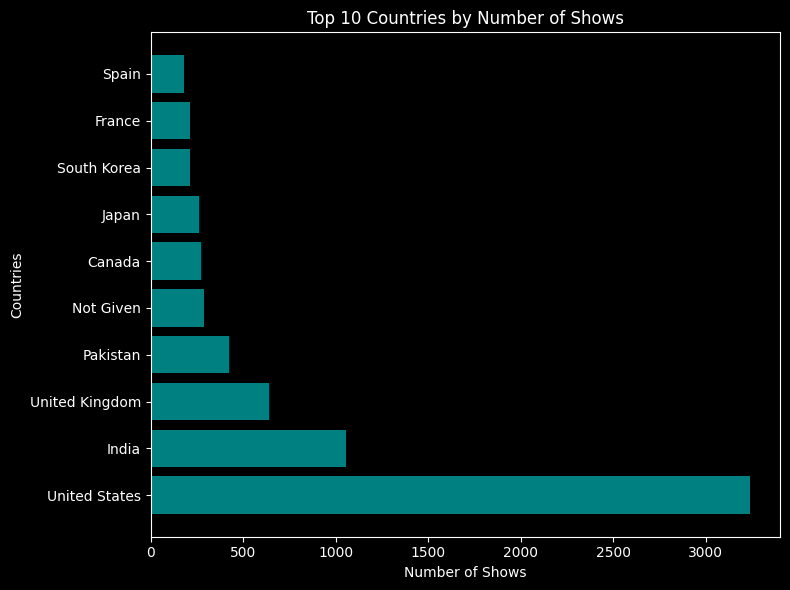

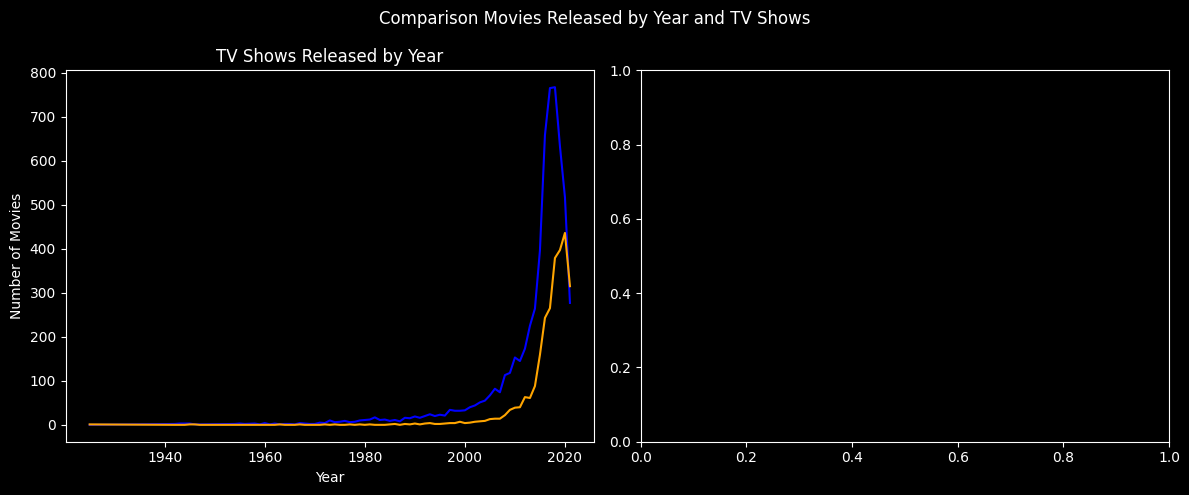

In [27]:
#import libraries pandas and matplotlib
import pandas as pd
import matplotlib.pyplot as plt

#load the data
df = pd.read_csv('netflix1.csv')

#clean the data
df = df.dropna(subset=['type', 'show_id','type','title','director','country','date_added','release_year','rating','duration','listed_in'])

type_counts = df['type'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(type_counts.index, type_counts.values, color=['skyblue', 'orange'])
plt.title('Number of Movies and TV Shows on Netflix')
plt.xlabel('Types')
plt.ylabel('Counts')
plt.tight_layout()
plt.savefig('Movies_TVShows_Netflix.png')
plt.show()

rating_counts = df['rating'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Percentage of content Rating')
plt.tight_layout()
plt.savefig('content_rating-pie.png')
plt.show()

movie_df = df[df['type']== 'Movie'].copy()
movie_df['duration_int'] = movie_df['duration'].str.replace('min','').astype(int)

plt.figure(figsize=(8,6))
plt.hist(movie_df['duration_int'], bins=30, color='purple', edgecolor='black')
plt.title('Histogram of Duration of Movies')
plt.xlabel('Duration of Movies')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig('movie_duration_hist.png')
plt.tight_layout()
plt.show()

release_counts = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(10,6))
plt.scatter(release_counts.index, release_counts.values, color='Blue')
plt.title('Release Year VS Number of Movies')
plt.xlabel('Release Year')
plt.ylabel('Number of Shows')
plt.tight_layout()
plt.savefig('release_year_shows_scatter.png')
plt.show()

country_counts = df['country'].value_counts().head(10)
plt.figure(figsize=(8,6))
plt.barh(country_counts.index, country_counts.values, color='teal')
plt.title('Top 10 Countries by Number of Shows')
plt.xlabel('Number of Shows')
plt.ylabel('Countries')
plt.tight_layout()
plt.savefig('country_top_10_shows.png')
plt.show()

content_by_year = df.groupby(['release_year','type']).size().unstack().fillna(0)
fig, ax = plt.subplots(1,2, figsize=(12,5))

#first subplot:movies
ax[0].plot(content_by_year.index, content_by_year['Movie'], color='blue')
ax[0].set_title('Movies Released by Year')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Number of Movies')

#second  subplot:TV Shows
ax[0].plot(content_by_year.index, content_by_year['TV Show'], color='orange')
ax[0].set_title('TV Shows Released by Year')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Number of Movies')

fig.suptitle('Comparison Movies Released by Year and TV Shows')
plt.tight_layout()
plt.savefig('Movies_TV_Shows_Comparison.png')
plt.show()
